
# ML Exam Playground (From Your Slides → Code)

This notebook is a **single mini-project** where every exam topic becomes a tiny working build.

**How to use (exam mode):**
- Run cells top → bottom.
- For each module:
  1) Read the short concept notes (1–2 mins)
  2) Run the code
  3) Answer the mini-questions at the end of the module

You’ll implement most algorithms **from scratch** (NumPy), so the logic is crystal clear.



## 0) Setup
We’ll use only NumPy + Matplotlib (plus small helper functions).


In [25]:

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)
print("Random numbers:", rng)


Random numbers: Generator(PCG64)



### Helpers: train/test split + standardization


In [2]:

def train_test_split(X, y, test_size=0.25, seed=0):
    rng_local = np.random.default_rng(seed)
    idx = np.arange(len(X))
    rng_local.shuffle(idx)
    cut = int(len(X) * (1 - test_size))
    train_idx, test_idx = idx[:cut], idx[cut:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def standardize_fit(X):
    mu = X.mean(axis=0, keepdims=True)
    sigma = X.std(axis=0, keepdims=True) + 1e-12
    return mu, sigma

def standardize_transform(X, mu, sigma):
    return (X - mu) / sigma



### Metrics (Classification)


In [54]:

def confusion_matrix(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn

def accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(y_true == y_pred)

def precision_recall_f1(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn + 1e-12)
    f1   = 2 * prec * rec / (prec + rec + 1e-12)
    return prec, rec, f1

def print_classification_report(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    acc = accuracy(y_true, y_pred)
    prec, rec, f1 = precision_recall_f1(y_true, y_pred)
    print("Confusion matrix (tp, tn, fp, fn):", (tp, tn, fp, fn))
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1:        {f1:.4f}")



## 1) Linear Regression (Best-fit line, RSS/RMSE, Gradient Descent)

**Concept in 1 minute**
- We predict a continuous value with a line:  

  \(\hat{y} = w x + b\)
- **Residual** = (true − predicted)
- Best-fit line minimizes **RSS** (Residual Sum of Squares) and often we report **RMSE**.
- We can learn \(w, b\) by **gradient descent**; **step size (learning rate) matters**.


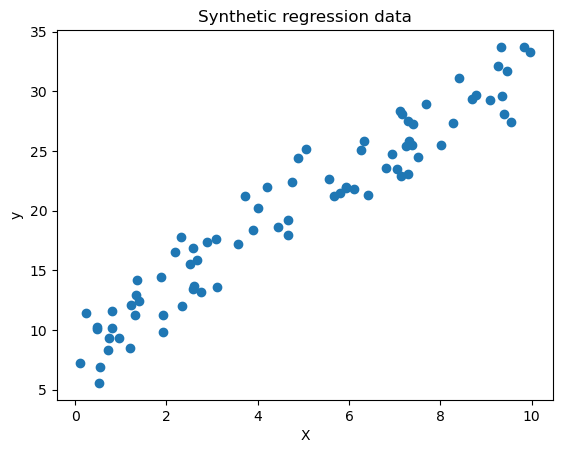

In [66]:

# Synthetic 1D regression data (salary vs years of experience vibe)
n = 80
X = rng.uniform(0, 10, size=(n, 1))
true_w, true_b = 2.5, 8.0
noise = rng.normal(0, 2.0, size=(n, 1))
y = (true_w * X + true_b + noise).reshape(-1)

# Plot
plt.figure()
plt.scatter(X[:,0], y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic regression data")
plt.show()


In [67]:

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def fit_linear_regression_gd(X, y, lr=0.01, epochs=2000):
    # X: (n,1)
    X1 = X.reshape(-1, 1)
    n = len(X1)
    w = 0.0
    b = 0.0
    history = []
    for t in range(epochs):
        y_hat = w * X1[:, 0] + b
        err = y_hat - y
        # gradients of MSE
        dw = (2/n) * np.sum(err * X1[:, 0])
        db = (2/n) * np.sum(err)
        w -= lr * dw
        b -= lr * db
        if t % 20 == 0:
            history.append(rmse(y, y_hat))
    return w, b, np.array(history)

# Try two learning rates to see "step size matters"
w1, b1, h1 = fit_linear_regression_gd(X, y, lr=0.02, epochs=2000)
w2, b2, h2 = fit_linear_regression_gd(X, y, lr=0.01,  epochs=2000)

print("LR=0.02 -> w, b:", w1, b1, "final RMSE:", h1[-1])
print("LR=0.20 -> w, b:", w2, b2, "final RMSE:", h2[-1])


LR=0.02 -> w, b: 2.401622976131579 8.557063967394345 final RMSE: 2.012693632140275
LR=0.20 -> w, b: 2.4016420008873425 8.55693842357642 final RMSE: 2.0126936335186936


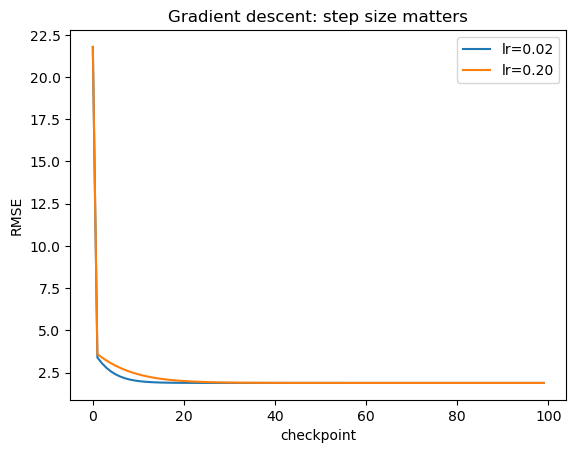

In [50]:

# Plot RMSE curves
plt.figure()
plt.plot(h1, label="lr=0.02")
plt.plot(h2, label="lr=0.20")
plt.xlabel("checkpoint")
plt.ylabel("RMSE")
plt.title("Gradient descent: step size matters")
plt.legend()
plt.show()


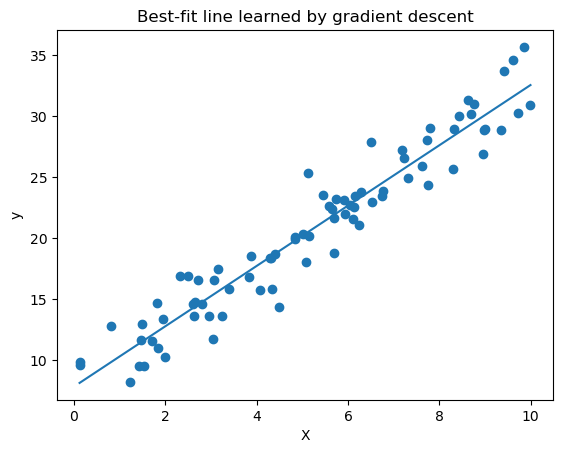

In [53]:

# Plot fitted line for the stable run
y_hat = w1 * X[:,0] + b1
plt.figure()
plt.scatter(X[:,0], y)
xs = np.linspace(X[:,0].min(), X[:,0].max(), 100)
plt.plot(xs, w1*xs + b1)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Best-fit line learned by gradient descent")
plt.show()



**Mini-questions (exam style)**
1) What is a residual?  
2) Why does RMSE “punish” large errors more than MAE?  
3) What happens if learning rate is too big? Too small?



## 2) Logistic Regression (Sigmoid, Threshold 0.5, Cross-Entropy)

**Concept in 1 minute**
- We want probabilities for class 1, so we use **sigmoid**:  

  \(\sigma(z)=\frac{1}{1+e^{-z}}\)
- Model: \(\hat{y}=\sigma(w^T x + b)\)
- Convert probability to class with a **threshold** (commonly 0.5).
- Train by minimizing **cross-entropy loss**.


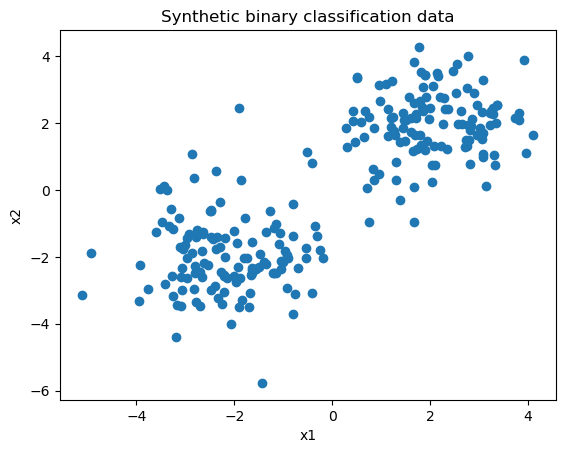

In [8]:

# Synthetic 2D classification (linearly separable-ish)
n = 250
X0 = rng.normal(loc=(-2, -2), scale=1.0, size=(n//2, 2))
X1 = rng.normal(loc=( 2,  2), scale=1.0, size=(n//2, 2))
X = np.vstack([X0, X1])
y = np.array([0]*(n//2) + [1]*(n//2))

# Shuffle
idx = rng.permutation(n)
X, y = X[idx], y[idx]

plt.figure()
plt.scatter(X[:,0], X[:,1])
plt.title("Synthetic binary classification data")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()


In [9]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_loss(y_true, p):
    # binary cross-entropy
    eps = 1e-12
    p = np.clip(p, eps, 1-eps)
    return -np.mean(y_true*np.log(p) + (1-y_true)*np.log(1-p))

def fit_logistic_regression_gd(X, y, lr=0.1, epochs=2000):
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    hist = []
    for t in range(epochs):
        z = X @ w + b
        p = sigmoid(z)
        # gradients
        dw = (1/n) * (X.T @ (p - y))
        db = (1/n) * np.sum(p - y)
        w -= lr * dw
        b -= lr * db
        if t % 50 == 0:
            hist.append(logistic_loss(y, p))
    return w, b, np.array(hist)

# Standardize features (helps GD)
mu, sigma = standardize_fit(X)
Xs = standardize_transform(X, mu, sigma)

w, b, hist = fit_logistic_regression_gd(Xs, y, lr=0.2, epochs=3000)
print("w:", w, "b:", b, "final loss:", hist[-1])


w: [4.5376 5.0469] b: 0.24255180835189646 final loss: 0.009347407831805947


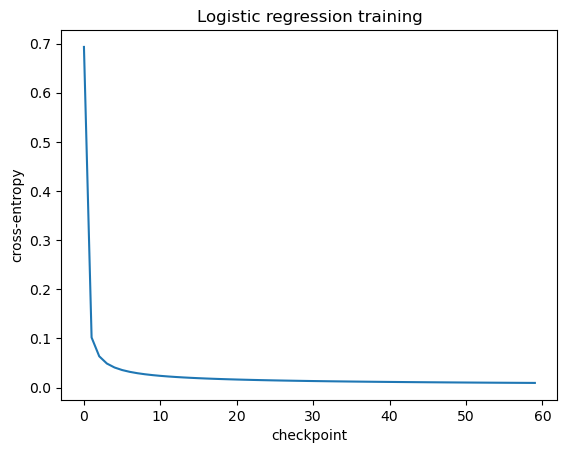

In [10]:

# Loss curve
plt.figure()
plt.plot(hist)
plt.xlabel("checkpoint")
plt.ylabel("cross-entropy")
plt.title("Logistic regression training")
plt.show()


In [11]:

# Predict with threshold 0.5
p = sigmoid(Xs @ w + b)
y_pred = (p >= 0.5).astype(int)
print_classification_report(y, y_pred)


Confusion matrix (tp, tn, fp, fn): (np.int64(125), np.int64(125), np.int64(0), np.int64(0))
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1:        1.0000



**Mini-questions (exam style)**
1) Why do we need sigmoid? (What goes wrong with a plain line?)  
2) What does “threshold = 0.5” mean?  
3) Why is cross-entropy harsh on confident wrong predictions?



## 3) k-Nearest Neighbors (Instance-based, Distance Metrics, Choosing k)

**Concept in 1 minute**
- Instance-based: store training points, predict by comparing distances.
- For classification: majority vote of k nearest neighbors.
- For regression: average of k nearest neighbors.
- k too small → overfit/noise; k too big → underfit/smooth.


In [12]:

def euclidean_distance(a, b):
    # a: (d,), b: (d,)
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict(X_train, y_train, X_test, k=5):
    y_pred = []
    for x in X_test:
        dists = np.sum((X_train - x) ** 2, axis=1)  # squared euclidean
        nn_idx = np.argsort(dists)[:k]
        votes = y_train[nn_idx]
        # majority vote
        y_pred.append(int(np.round(votes.mean())))  # works for 0/1 labels
    return np.array(y_pred)

# Use previous classification data
X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.30, seed=42)

for k in [1, 3, 5, 15, 51]:
    yp = knn_predict(X_train, y_train, X_test, k=k)
    print(f"k={k:>2}  acc={accuracy(y_test, yp):.4f}")


k= 1  acc=0.9867
k= 3  acc=0.9867
k= 5  acc=0.9867
k=15  acc=0.9867
k=51  acc=1.0000



**Mini-questions (exam style)**
1) Why do we often standardize features before KNN?  
2) k=1 tends to do what (overfit/underfit)? Why?  
3) Name 2 distance metrics besides Euclidean.



## 4) Decision Tree (ID3-style): Entropy + Information Gain

**Concept in 1 minute**
- Tree has **root**, **decision nodes**, **leaf nodes**.
- ID3 grows the tree top-down (greedy): choose the split with best **information gain**.
- Stopping conditions: all same class, no attributes left, etc.


In [13]:

# Tiny categorical dataset (Play Tennis-style)
# Features: Outlook, Wind
# Label: Play (0/1)
data = [
    ("Sunny",   "Weak",   0),
    ("Sunny",   "Strong", 0),
    ("Overcast","Weak",   1),
    ("Rain",    "Weak",   1),
    ("Rain",    "Strong", 0),
    ("Overcast","Strong", 1),
    ("Sunny",   "Weak",   0),
    ("Rain",    "Weak",   1),
]
X_cat = [d[:2] for d in data]
y_cat = np.array([d[2] for d in data])

feature_names = ["Outlook", "Wind"]


In [14]:

from collections import Counter, defaultdict

def entropy(labels):
    counts = Counter(labels)
    n = len(labels)
    ent = 0.0
    for c in counts.values():
        p = c / n
        ent -= p * np.log2(p + 1e-12)
    return ent

def info_gain(X, y, feature_index):
    base = entropy(y)
    # partition by feature value
    parts = defaultdict(list)
    for xi, yi in zip(X, y):
        parts[xi[feature_index]].append(yi)
    n = len(y)
    cond = 0.0
    for ys in parts.values():
        ys = np.array(ys)
        cond += (len(ys)/n) * entropy(ys)
    return base - cond

print("Base entropy:", entropy(y_cat))
for j, name in enumerate(feature_names):
    print(name, "info gain:", info_gain(X_cat, y_cat, j))


Base entropy: 0.9999999999971146
Outlook info gain: 0.655639062228665
Wind info gain: 0.04879494069539858


In [15]:

# Minimal ID3 tree (depth-limited for clarity)

class Node:
    def __init__(self, feature=None, prediction=None):
        self.feature = feature
        self.prediction = prediction
        self.children = {}  # value -> Node

def majority_class(y):
    return Counter(y).most_common(1)[0][0]

def id3_train(X, y, features):
    # If pure
    if len(set(y)) == 1:
        return Node(prediction=y[0])
    # If no features left
    if len(features) == 0:
        return Node(prediction=majority_class(y))
    # Choose best feature
    gains = [(info_gain(X, y, f), f) for f in features]
    _, best_f = max(gains, key=lambda t: t[0])
    node = Node(feature=best_f)

    # Split
    values = sorted(set(x[best_f] for x in X))
    for v in values:
        X_sub = []
        y_sub = []
        for xi, yi in zip(X, y):
            if xi[best_f] == v:
                X_sub.append(xi)
                y_sub.append(yi)
        if len(y_sub) == 0:
            node.children[v] = Node(prediction=majority_class(y))
        else:
            remaining = [f for f in features if f != best_f]
            node.children[v] = id3_train(X_sub, np.array(y_sub), remaining)
    return node

def id3_predict_one(node, x):
    while node.prediction is None:
        v = x[node.feature]
        if v not in node.children:
            return 0
        node = node.children[v]
    return node.prediction

tree = id3_train(X_cat, y_cat, features=[0,1])

for xi, yi in zip(X_cat, y_cat):
    print(xi, "pred:", id3_predict_one(tree, xi), "true:", yi)


('Sunny', 'Weak') pred: 0 true: 0
('Sunny', 'Strong') pred: 0 true: 0
('Overcast', 'Weak') pred: 1 true: 1
('Rain', 'Weak') pred: 1 true: 1
('Rain', 'Strong') pred: 0 true: 0
('Overcast', 'Strong') pred: 1 true: 1
('Sunny', 'Weak') pred: 0 true: 0
('Rain', 'Weak') pred: 1 true: 1



**Mini-questions (exam style)**
1) What are root node / decision node / leaf node?  
2) Why is ID3 called “greedy”?  
3) What’s one stopping condition for tree growth?



## 5) PCA (Mean center → Covariance → Eigenvectors → Project)

**Concept in 1 minute**
- PCA finds **orthogonal** axes (principal components) that capture maximum variance.
- Steps: subtract mean → compute covariance → eigen decomposition → sort by eigenvalues → choose top M.
- Principal components are **uncorrelated** because they’re orthogonal.


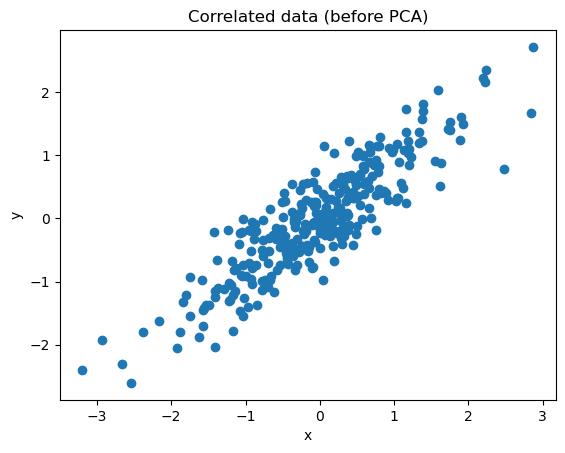

In [16]:

# Make correlated 2D data
n = 300
x = rng.normal(0, 1, size=n)
y = 0.8*x + rng.normal(0, 0.4, size=n)
X = np.column_stack([x, y])

plt.figure()
plt.scatter(X[:,0], X[:,1])
plt.title("Correlated data (before PCA)")
plt.xlabel("x"); plt.ylabel("y")
plt.show()


In [17]:

def pca_fit(X):
    # mean center
    mu = X.mean(axis=0, keepdims=True)
    Z = X - mu
    # covariance
    C = (Z.T @ Z) / (len(X) - 1)
    # eigen decomposition (C is symmetric => use eigh)
    evals, evecs = np.linalg.eigh(C)
    # sort descending
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]
    return mu, evals, evecs

def pca_transform(X, mu, W, m_components):
    Z = X - mu
    Wm = W[:, :m_components]
    return Z @ Wm

mu, evals, W = pca_fit(X)
print("Eigenvalues:", evals)
print("Top eigenvector:", W[:,0])

# Variance explained
explained = evals / evals.sum()
print("Explained variance ratio:", explained)


Eigenvalues: [1.5969 0.0968]
Top eigenvector: [-0.7415 -0.671 ]
Explained variance ratio: [0.9429 0.0571]


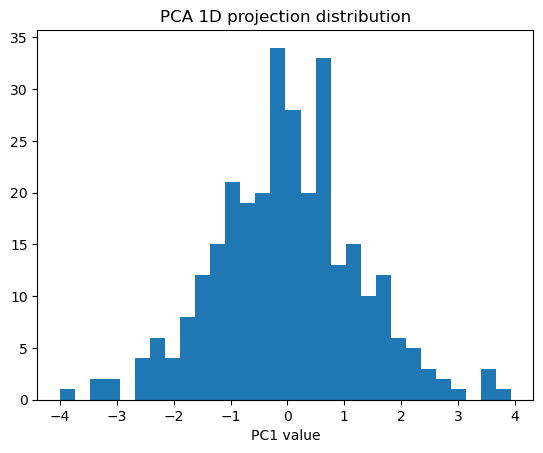

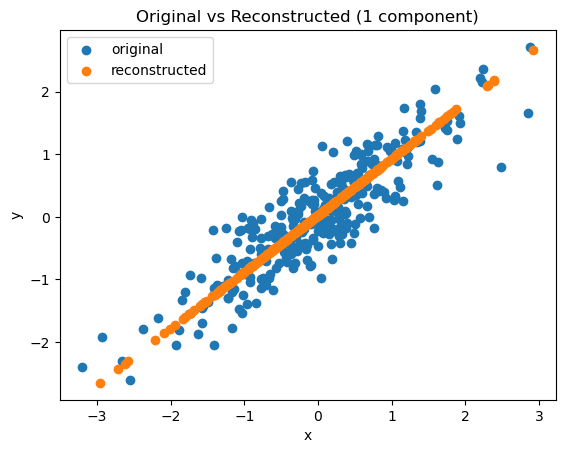

In [18]:

# Project to 1D
Y1 = pca_transform(X, mu, W, m_components=1)

plt.figure()
plt.hist(Y1[:,0], bins=30)
plt.title("PCA 1D projection distribution")
plt.xlabel("PC1 value")
plt.show()

# Reconstruct back to 2D (approx) to visualize loss
X_hat = (Y1 @ W[:, :1].T) + mu

plt.figure()
plt.scatter(X[:,0], X[:,1], label="original")
plt.scatter(X_hat[:,0], X_hat[:,1], label="reconstructed")
plt.title("Original vs Reconstructed (1 component)")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()



**Mini-questions (exam style)**
1) Why do we subtract the mean first?  
2) What do eigenvalues represent in PCA?  
3) Why are principal components uncorrelated?



## 6) Perceptron (Linear Binary Classifier + Perceptron Learning Rule)

**Concept in 1 minute**
- Perceptron computes a weighted sum + bias, then applies an activation/threshold.
- It’s a **linear** classifier (works if data is linearly separable).
- Learning rule: update weights based on (true − predicted) * input (scaled by learning rate).


In [19]:

def perceptron_fit(X, y, lr=0.1, epochs=50):
    # y in {-1, +1}
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    for _ in range(epochs):
        errors = 0
        for xi, yi in zip(X, y):
            y_hat = 1 if (xi @ w + b) >= 0 else -1
            if yi != y_hat:
                w = w + lr * yi * xi
                b = b + lr * yi
                errors += 1
        if errors == 0:
            break
    return w, b

def perceptron_predict(X, w, b):
    return np.where((X @ w + b) >= 0, 1, -1)

# Use a linearly separable subset of earlier data
X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.30, seed=1)
y_train_pm = np.where(y_train==1, 1, -1)
y_test_pm  = np.where(y_test==1,  1, -1)

w, b = perceptron_fit(X_train, y_train_pm, lr=0.1, epochs=100)
pred_pm = perceptron_predict(X_test, w, b)
print("Perceptron test accuracy:", np.mean(pred_pm == y_test_pm))


Perceptron test accuracy: 1.0



**Mini-questions (exam style)**
1) When does perceptron converge?  
2) Why can’t a single perceptron solve XOR?



## 7) Tiny Neural Network (2-layer) + Backprop (Chain Rule)

**Concept in 1 minute**
- Forward propagation: compute weighted sums → activation → next layer.
- Backprop: compute gradients using **chain rule**, update weights with gradient descent.
- Sigmoid derivative: \(\sigma'(z)=\sigma(z)(1-\sigma(z))\).


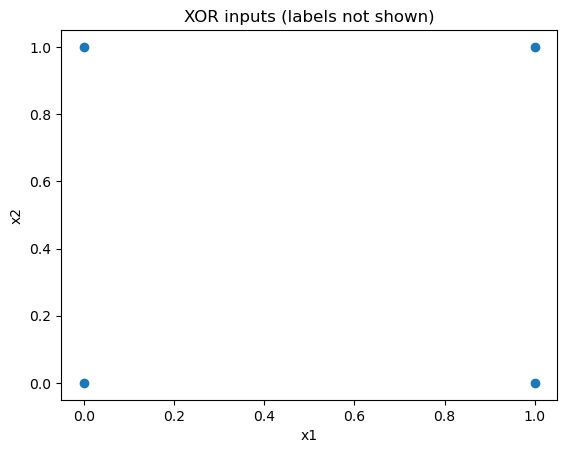

In [20]:

# XOR dataset (classic "perceptron fails" but 2-layer NN works)
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([[0],[1],[1],[0]], dtype=float)

plt.figure()
plt.scatter(X[:,0], X[:,1])
plt.title("XOR inputs (labels not shown)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()


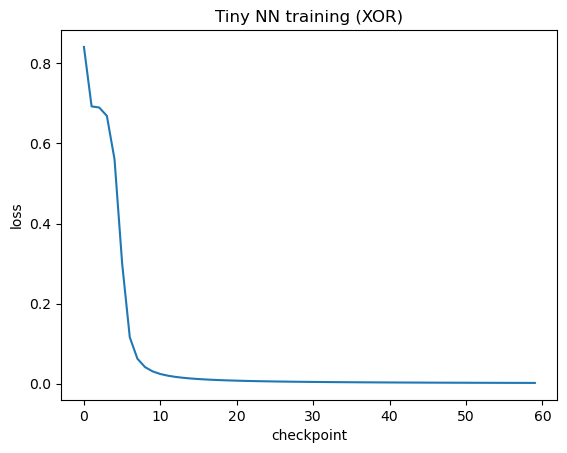

Predicted probabilities:
[[0.   ]
 [0.998]
 [0.998]
 [0.004]]
Predicted classes:
[0 1 1 0]
True classes:
[0 1 1 0]


In [21]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_grad(a):
    # a is sigmoid(z)
    return a * (1 - a)

class TinyNN:
    def __init__(self, in_dim=2, hidden_dim=4, out_dim=1, seed=0):
        r = np.random.default_rng(seed)
        self.W1 = r.normal(0, 1, size=(in_dim, hidden_dim)) * 0.8
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = r.normal(0, 1, size=(hidden_dim, out_dim)) * 0.8
        self.b2 = np.zeros((1, out_dim))

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = sigmoid(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = sigmoid(z2)
        cache = (X, z1, a1, z2, a2)
        return a2, cache

    def loss(self, y_true, y_pred):
        eps = 1e-12
        y_pred = np.clip(y_pred, eps, 1-eps)
        return -np.mean(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))

    def train(self, X, y, lr=1.0, epochs=5000):
        hist = []
        n = len(X)
        for t in range(epochs):
            y_pred, cache = self.forward(X)
            X0, z1, a1, z2, a2 = cache

            # Backprop (chain rule)
            # dL/da2 then da2/dz2 then dz2/dW2, etc.
            dL_da2 = (a2 - y) / (n * (a2*(1-a2) + 1e-12))   # stable-ish for BCE+sigmoid
            da2_dz2 = sigmoid_grad(a2)
            dL_dz2 = dL_da2 * da2_dz2

            dW2 = a1.T @ dL_dz2
            db2 = np.sum(dL_dz2, axis=0, keepdims=True)

            dL_da1 = dL_dz2 @ self.W2.T
            da1_dz1 = sigmoid_grad(a1)
            dL_dz1 = dL_da1 * da1_dz1

            dW1 = X0.T @ dL_dz1
            db1 = np.sum(dL_dz1, axis=0, keepdims=True)

            # Gradient descent update
            self.W2 -= lr * dW2
            self.b2 -= lr * db2
            self.W1 -= lr * dW1
            self.b1 -= lr * db1

            if t % 100 == 0:
                hist.append(self.loss(y, y_pred))
        return np.array(hist)

nn = TinyNN(hidden_dim=4, seed=0)
hist = nn.train(X, y, lr=1.0, epochs=6000)

plt.figure()
plt.plot(hist)
plt.xlabel("checkpoint")
plt.ylabel("loss")
plt.title("Tiny NN training (XOR)")
plt.show()

pred, _ = nn.forward(X)
print("Predicted probabilities:")
print(pred.round(3))
print("Predicted classes:")
print((pred >= 0.5).astype(int).ravel())
print("True classes:")
print(y.ravel().astype(int))



**Mini-questions (exam style)**
1) Why does a 2-layer NN solve XOR but perceptron can’t?  
2) In backprop, what does “chain rule” mean in words?  
3) What is the role of the learning rate here?



## Bonus: Overfitting vs Underfitting (fast demo)

**Idea**
- Underfitting: model too simple, can’t capture pattern.
- Overfitting: model too complex, learns noise → bad on new data.


In [22]:

# Polynomial regression demo: show under/overfitting
n = 80
X = rng.uniform(-3, 3, size=(n, 1))
y = (0.5*X[:,0]**3 - X[:,0]**2 + 2*X[:,0] + rng.normal(0, 3, size=n))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, seed=0)

def poly_features(X, degree):
    x = X[:,0]
    feats = [x**k for k in range(1, degree+1)]
    return np.column_stack(feats)

def fit_ridge_closed_form(X, y, lam=0.0):
    # add bias term
    Xb = np.column_stack([np.ones(len(X)), X])
    I = np.eye(Xb.shape[1])
    I[0,0] = 0  # don't regularize bias
    w = np.linalg.inv(Xb.T@Xb + lam*I) @ (Xb.T@y)
    return w

def predict_linear(X, w):
    Xb = np.column_stack([np.ones(len(X)), X])
    return Xb @ w

def eval_degree(deg, lam=0.0):
    Phi_tr = poly_features(X_train, deg)
    Phi_te = poly_features(X_test, deg)
    w = fit_ridge_closed_form(Phi_tr, y_train, lam=lam)
    tr_rmse = rmse(y_train, predict_linear(Phi_tr, w))
    te_rmse = rmse(y_test,  predict_linear(Phi_te, w))
    return tr_rmse, te_rmse

for deg in [1, 3, 10]:
    tr, te = eval_degree(deg, lam=0.0)
    print(f"degree={deg:>2}  train RMSE={tr:.3f}  test RMSE={te:.3f}")


degree= 1  train RMSE=4.152  test RMSE=5.484
degree= 3  train RMSE=2.808  test RMSE=3.171
degree=10  train RMSE=2.587  test RMSE=4.156



**Mini-questions**
1) Which degree looks like underfitting? Which looks like overfitting?  
2) How does regularization (like ridge) help?
